# Day 3: Data Analysis - Home Notebook
## Objectives

In this session, you will use Python to:
- Load and inspect a dataset with pandas.
- Summarize numeric and categorical variables.
- Make exploratory plots.
- Compare two variables and interpret the result.
- Save a figure and write a short conclusion.

This notebook follows the same style as the previous home notebooks: read the question, run the code, and familiarize with coding. Take this notebook to test different parameters and try to solve problems on your own.

---
## 1) Which packages do you need for data analysis?

Import the libraries you will need for this homework.

In [2]:
import pandas as pd
import seaborn as sns 
import pathlib 
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy import stats
import statsmodels.formula.api as smf 

---
## 2) How do you load the dataset and inspect its structure?

Use the cleaned penguin dataset from Day 2 (`penguins_clean.csv`). Your goal is to check that the file loads correctly and to inspect the table structure before making any plots or summaries.


In [4]:
data_folder_path = "/Users/Farisha/OneDrive - University of Bergen/Day_2/penguins_clean.csv"
file_path = pathlib.Path(data_folder_path)
df = pd.read_csv(file_path)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   row_id             333 non-null    int64  
 1   species            333 non-null    str    
 2   island             333 non-null    str    
 3   bill_length_mm     333 non-null    float64
 4   bill_depth_mm      333 non-null    float64
 5   flipper_length_mm  333 non-null    float64
 6   body_mass_g        333 non-null    float64
 7   sex                333 non-null    str    
 8   observation_year   333 non-null    int64  
dtypes: float64(4), int64(2), str(3)
memory usage: 29.3 KB


---
## 3) Which numeric variable would you explore first?

Choose one numeric variable from the dataset and print its summary statistics. Pay attention to the mean, median, standard deviation, and range. This helps you understand the distribution before plotting it.


In [5]:
print(df["body_mass_g"].describe())

count     333.000000
mean     4207.057057
std       805.215802
min      2700.000000
25%      3550.000000
50%      4050.000000
75%      4775.000000
max      6300.000000
Name: body_mass_g, dtype: float64


---
## 4) Set up the right data type and pick which categorical variable would you explore next?

The dataset contains both numeric and categorical information. Before plotting, make sure that the categorical columns are stored as text-like values. Then choose one categorical variable and count how often each category appears.


In [6]:
for column in ["row_id","sex", "species", "island", "observation_year"]:
    df[column] = df[column].astype('str')

df.info()
print(df["island"].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   row_id             333 non-null    str    
 1   species            333 non-null    str    
 2   island             333 non-null    str    
 3   bill_length_mm     333 non-null    float64
 4   bill_depth_mm      333 non-null    float64
 5   flipper_length_mm  333 non-null    float64
 6   body_mass_g        333 non-null    float64
 7   sex                333 non-null    str    
 8   observation_year   333 non-null    str    
dtypes: float64(4), str(5)
memory usage: 31.5 KB
island
Biscoe       163
Dream        123
Torgersen     47
Name: count, dtype: int64


---
## 5) How can you inspect the distribution of a numeric variable?

Make a histogram and a boxplot for the numeric variable you chose. Use this to identify skewness, spread, and possible outliers.


<Axes: xlabel='body_mass_g', ylabel='Count'>

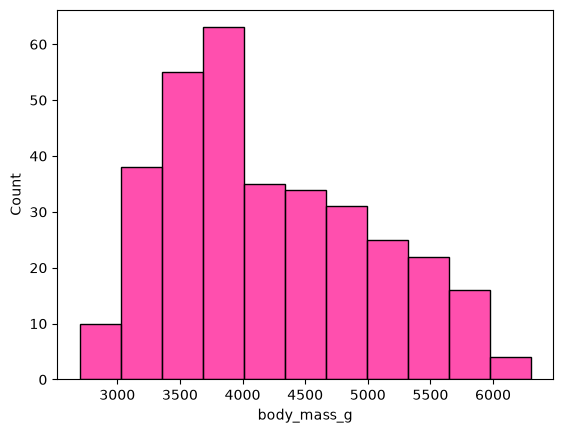

In [7]:
sns.histplot(x = df["body_mass_g"], color = "deeppink")

<Axes: xlabel='body_mass_g'>

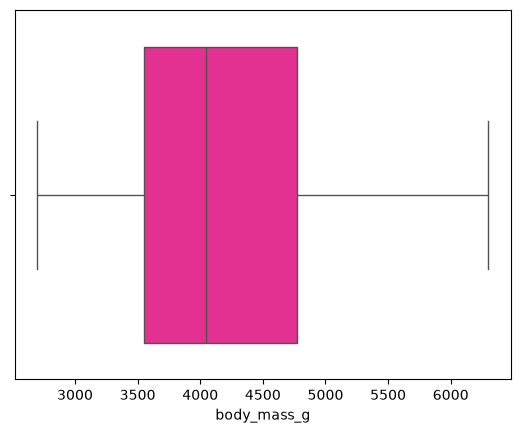

In [8]:
sns.boxplot(x = df["body_mass_g"], color = "deeppink")

---
## 6) How can you inspect the distribution of a categorical variable?

Create a count plot for the category you selected. This helps you understand whether the groups are balanced or whether one category dominates the dataset.


<Axes: xlabel='island', ylabel='count'>

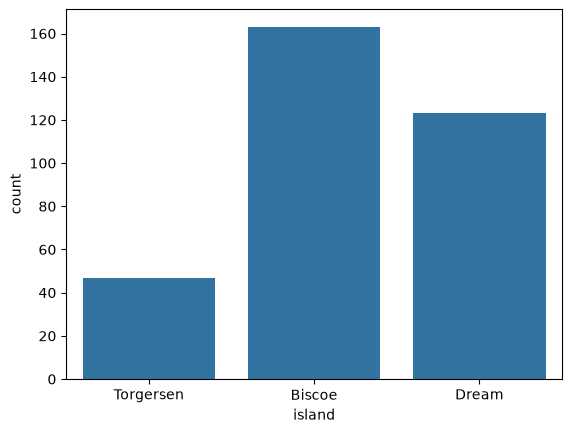

In [9]:
sns.countplot(data = df, x = "island")

---
## 7) How do you compare two quantitative variables?

Choose two numeric variables and make a scatter plot with a regression line. This helps you inspect whether the variables move together, and whether a simple linear trend is present.


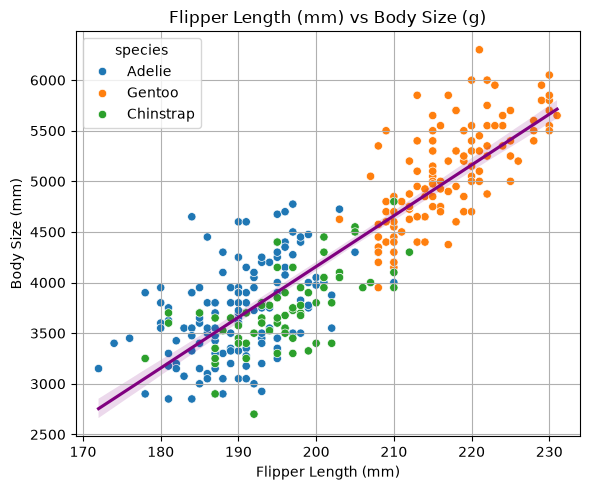

In [10]:
quantitative_x = "flipper_length_mm"
quantitative_y = "body_mass_g"

fig, ax = plt.subplots(figsize = (6,5))
sns.scatterplot(data = df, x = quantitative_x, y = quantitative_y, ax = ax, hue = "species")
sns.regplot(data = df, x = quantitative_x, y = quantitative_y, scatter = False, ax = ax, color = "purple")
ax.set_title("Flipper Length (mm) vs Body Size (g)")
ax.set_xlabel("Flipper Length (mm)")
ax.set_ylabel("Body Size (mm)")
ax.grid(True)
plt.tight_layout()
plt.savefig("two_variables_scatterplot2.png", dpi=300)
plt.show()

---
## 8) How do you compare one numeric variable across two groups?

Select one grouping variable and one numeric outcome. Then use a boxplot to compare the distribution of the outcome across the two groups.


<Axes: xlabel='flipper_length_mm', ylabel='island'>

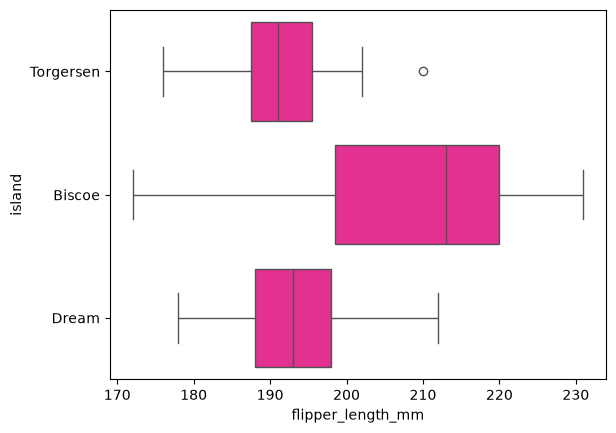

In [38]:
sns.boxplot(x = df["flipper_length_mm"], y = df["island"], color = "deeppink")

---
## 9) How do you save one figure and wrap up the analysis?

Save one figure to disk and use a short written interpretation to explain what the plot shows. This is the same logic you will use in reports and assignments.


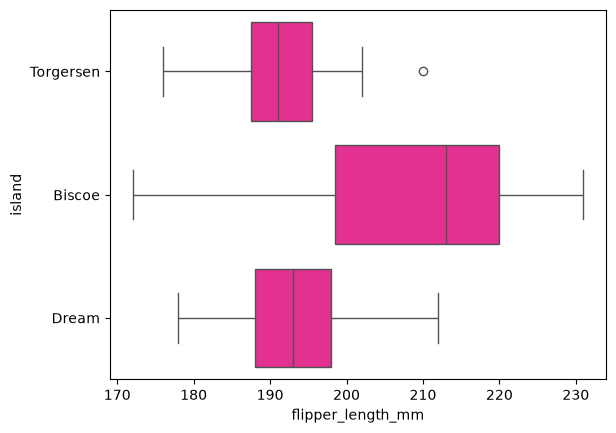

In [42]:
island_flipper_length_mm_comparison = sns.boxplot(x = df["flipper_length_mm"], y = df["island"], color = "deeppink")
plt.savefig("island_flipper_length_mm_comparison.png", dpi = 300) 

---
## 10) Compare two groups with a simple statistical question

Use the same dataset and answer the following question in one or two sentences:

- Does the distribution of `body_mass_g` look different between `male` and `female` in  `Gentoo` penguins?
- Which plot would you use to answer this question, and why?
- Test if there is a statistically significant differance.


    row_id species  island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
146    153  Gentoo  Biscoe            46.1           13.2              211.0   
147    154  Gentoo  Biscoe            50.0           16.3              230.0   
148    155  Gentoo  Biscoe            48.7           14.1              210.0   
149    156  Gentoo  Biscoe            50.0           15.2              218.0   
150    157  Gentoo  Biscoe            47.6           14.5              215.0   
..     ...     ...     ...             ...            ...                ...   
260    271  Gentoo  Biscoe            47.2           13.7              214.0   
261    273  Gentoo  Biscoe            46.8           14.3              215.0   
262    274  Gentoo  Biscoe            50.4           15.7              222.0   
263    275  Gentoo  Biscoe            45.2           14.8              212.0   
264    276  Gentoo  Biscoe            49.9           16.1              213.0   

     body_mass_g     sex observation_ye

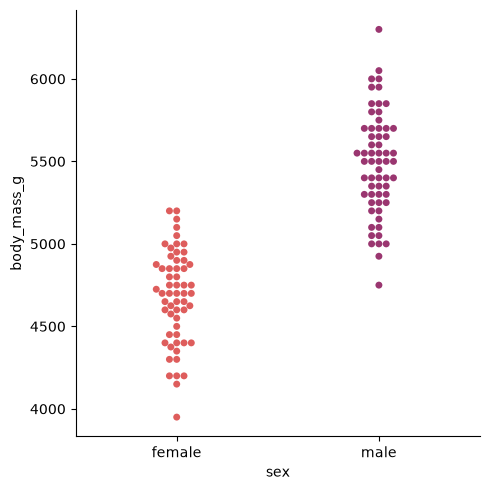

In [52]:
df_gentoo = df[df["species"] == "Gentoo"]
print(df_gentoo)

#From this dataset, it looks like all the males have a body mass above 5000 g, while most women are under 5000 g. 
#Overall it seems males in Gentoo penguins have higher body mass compared to females.

#Swarm plot allows us to visualize individual, non-overlapping observations for categorical data, which in our case is sex.
sns.catplot(data = df_gentoo, kind = "swarm", x = "sex", y = "body_mass_g", hue = "sex", palette = "flare")

#

---
## 11) Extra practice: Wrong Data Category
Set `observation_year` to float and plot a PCA. Compare with the figure seen in class and write a note on how mislabeled data types can bias your analysis.

In [55]:
for column in ["observation_year"]:
    df[column] = df[column].astype('float')

numeric_cols = df.select_dtypes(float).columns.tolist()
print(numeric_cols)

correlation = df[numeric_cols].corr()

pca_df = df[numeric_cols].dropna()
#PCA cannot handle missing values

X = StandardScaler().fit_transform(pca_df)

pca = PCA(n_components=2)
pcs = pca.fit_transform(X)

plot_df2 = pd.DataFrame(pcs, columns=["PC1", "PC2"], index=pca_df.index)
for meta in ("observation_year"):
    if meta in df.columns:
        plot_df2[meta] = df.loc[plot_df.index, meta].values

hue = "species"
style = "sex"
sns.scatterplot(data=plot_df2, x = "PC1", y = "PC2",  hue = hue, style = style)

['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'observation_year']


ValueError: Could not interpret value `species` for `hue`. An entry with this name does not appear in `data`.

---
## 12) Extra practice: modelling
Make a linear model that estimate `body_mass_g` using other other numerical variables and `species` and summarize your fitted model.


In [11]:
quantitative_x = "bill_length_mm"
quantitative_y = "bill_depth_mm"
group_column = "species"
outcome_column = "body_mass_g"

fig, ax = plt.subplots(figsize = (6,5))
sns.regplot(data = df, x = quantitative_x, quantitative_y, scatter = False, ax = ax)
ax.set_title("Bill Length (mm) vs Bill Depth (mm)")
ax.set_xlabel("Bill Length (mm)")
ax.set_ylabel("Bill Depth (mm)")
plt.tight_layout()
plt.show()

SyntaxError: positional argument follows keyword argument (2161719785.py, line 7)